# Sentiment Analysis
This notebook implements a sentiment analysis tool using **TF-IDF** and **Logistic Regression** using `numpy`, `pandas`, and `matplotlib`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Load the dataset
df = pd.read_csv('data.csv')

# Filter for positive and negative sentiments
df = df[df['sentiment'].str.strip().str.lower().isin(['positive', 'negative'])]

# Map labels: positive -> 1, negative -> 0
df['label'] = df['sentiment'].str.strip().str.lower().map({'positive': 1, 'negative': 0})

print(f"Dataset shape: {df.shape}")
df[['text', 'sentiment', 'label']].head()

Dataset shape: (300, 8)


,text,sentiment,label
0,What a great day!!! Looks like dream.,positive,1
1,"I feel sorry, I miss you here in the sea beach",positive,1
2,Don't angry me,negative,0
3,We attend in the class just for listening teac...,negative,0
4,"Those who want to go, let them go",negative,0


## 1. Text Preprocessing
We clean the text by converting to lowercase and removing non-alphabetic characters.

In [2]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)
documents = df['clean_text'].tolist()
labels = df['label'].values

# Simple Train-Test Split (80/20)
split = int(0.8 * len(documents))
train_docs, test_docs = documents[:split], documents[split:]
train_labels, test_labels = labels[:split], labels[split:]

## 2. TF-IDF Vectorizer
Building a vocabulary from the training set and calculate TF and IDF values.

In [3]:
class TFIDFVectorizer:
    def __init__(self):
        self.vocabulary = {}
        self.idf = {}
        
    def fit(self, docs):
        # Build vocabulary
        unique_words = set()
        for doc in docs:
            for word in doc.split():
                if len(word) > 1:
                    unique_words.add(word)
        
        self.vocabulary = {word: i for i, word in enumerate(sorted(list(unique_words)))}
        
        # Calculate IDF
        N = len(docs)
        for word in self.vocabulary:
            count = sum(1 for doc in docs if word in doc.split())
            self.idf[word] = np.log(N / (1 + count))
            
    def transform(self, docs):
        X = np.zeros((len(docs), len(self.vocabulary)))
        for i, doc in enumerate(docs):
            words = doc.split()
            if not words: continue
            for word in words:
                if word in self.vocabulary:
                    # TF = (count of word in doc) / (total words in doc)
                    tf = words.count(word) / len(words)
                    X[i, self.vocabulary[word]] = tf * self.idf[word]
        return X

vectorizer = TFIDFVectorizer()
vectorizer.fit(train_docs)
X_train = vectorizer.transform(train_docs)
X_test = vectorizer.transform(test_docs)

print(f"TF-IDF Matrix Shape: {X_train.shape}")

TF-IDF Matrix Shape: (240, 786)


## 3. Logistic Regression from Scratch
Using gradient descent to optimize the weights.

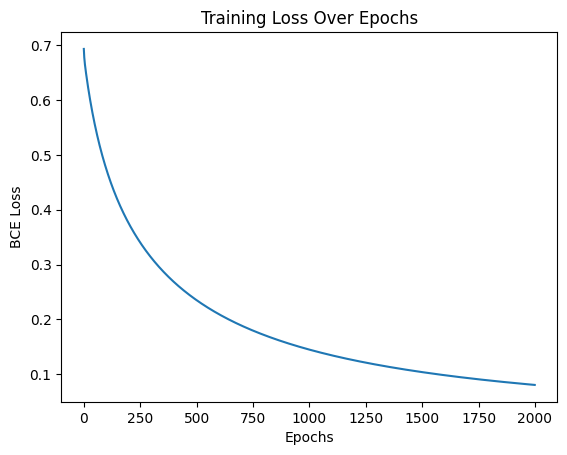

In [4]:
class LogisticRegression:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        
        for _ in range(self.epochs):
            model = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(model)
            
            # Binary Cross Entropy Loss
            loss = -np.mean(y * np.log(predictions + 1e-9) + (1-y) * np.log(1 - predictions + 1e-9))
            self.losses.append(loss)

            # Gradients
            dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
            db = (1 / n_samples) * np.sum(predictions - y)

            # Update weights
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        model = np.dot(X, self.weights) + self.bias
        return [1 if i > 0.5 else 0 for i in self.sigmoid(model)]

model = LogisticRegression(lr=1.0, epochs=2000)
model.fit(X_train, train_labels)

plt.plot(model.losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.show()

## 4. Evaluation
Checking accuracy on the test set.

Test Accuracy: 65.00%


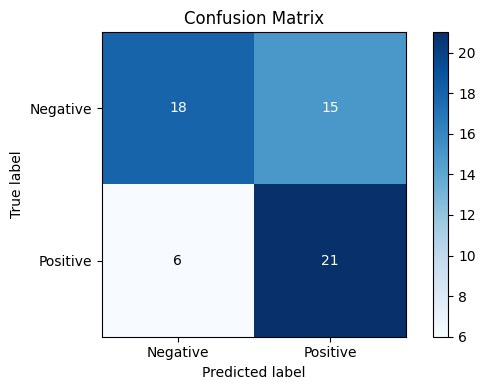

In [6]:
y_pred = np.array(model.predict(X_test))
y_true = np.array(test_labels)

# Calculate Accuracy
accuracy = np.mean(y_pred == y_true)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix from scratch
tp = sum((y_pred == 1) & (y_true == 1))
tn = sum((y_pred == 0) & (y_true == 0))
fp = sum((y_pred == 1) & (y_true == 0))
fn = sum((y_pred == 0) & (y_true == 1))

conf_matrix = np.array([[tn, fp], [fn, tp]])

# Visualization of Confusion Matrix
plt.figure(figsize=(6, 4))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])

# Add text annotations
thresh = conf_matrix.max() / 2.
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, format(conf_matrix[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()